In [18]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
import pandas as pd

file_path = "dataset.csv"

df = pd.read_csv(file_path, nrows=20000, low_memory=False)

print("Loaded rows:", len(df))
print("\nShape:", df.shape)
print("\nTop Columns:")
print(df.columns[:10])

Loaded rows: 20000

Shape: (20000, 151)

Top Columns:
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade'],
      dtype='object')



Top Missing Columns:
revol_bal_joint             100.0
member_id                   100.0
sec_app_fico_range_low      100.0
sec_app_fico_range_high     100.0
sec_app_earliest_cr_line    100.0
sec_app_inq_last_6mths      100.0
sec_app_mort_acc            100.0
sec_app_open_acc            100.0
sec_app_revol_util          100.0
sec_app_open_act_il         100.0
dtype: float64


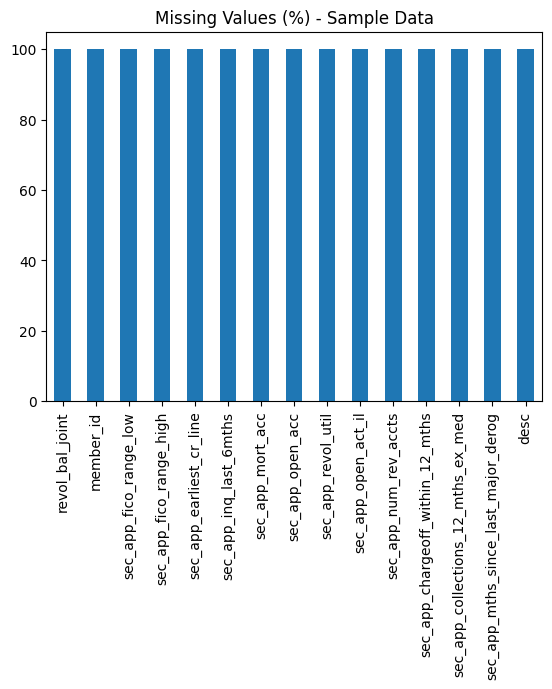


Loan Status Distribution:
loan_status
Fully Paid            14154
Charged Off            3571
Current                2120
Late (31-120 days)      106
In Grace Period          41
Late (16-30 days)         8
Name: count, dtype: int64


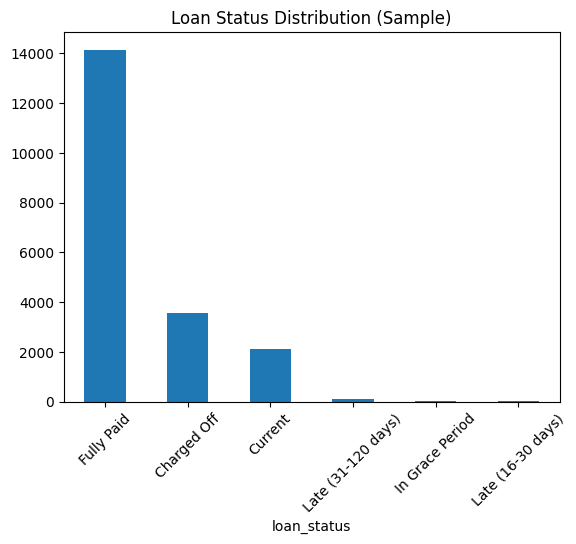

In [20]:
# STEP - Dealing with missing values
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("\nTop Missing Columns:")
print(missing_percent.head(10))

plt.figure()
missing_percent.head(15).plot(kind='bar')
plt.title("Missing Values (%) - Sample Data")
plt.xticks(rotation=90)
plt.show()

print("\nLoan Status Distribution:")
print(df['loan_status'].value_counts())

df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution (Sample)")
plt.xticks(rotation=45)
plt.show()

In [21]:
# STEP - SELECTIVE CLEANING

print("\nOriginal Loan Status:\n", df['loan_status'].value_counts())

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df = df.copy() 

df['target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

# Dropping columns with 100% missing data
missing_percent = df.isnull().mean() * 100
full_missing_cols = missing_percent[missing_percent == 100].index
print("\n100% Missing Columns:\n", list(full_missing_cols))

df.drop(columns=full_missing_cols, inplace=True)

print("\nShape after removing 100% missing columns:", df.shape)

# Creating missing flags
missing_percent = df.isnull().mean() * 100
high_missing_cols = missing_percent[missing_percent > 30].index

for col in high_missing_cols:
    df[col + "_missing_flag"] = df[col].isnull().astype(int)

# Imputation

# Numeric columns
num_cols = df.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())  

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])  
missing_after = df.isnull().mean() * 100


Original Loan Status:
 loan_status
Fully Paid            14154
Charged Off            3571
Current                2120
Late (31-120 days)      106
In Grace Period          41
Late (16-30 days)         8
Name: count, dtype: int64

100% Missing Columns:
 ['member_id', 'next_pymnt_d', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog']

Shape after removing 100% missing columns: (17725, 137)



Before Conversion:

         term emp_length  int_rate
0   36 months  10+ years     13.99
1   36 months  10+ years     11.99
2   60 months  10+ years     10.78
4   60 months    3 years     22.45
5   36 months    4 years     13.44

After Conversion:

   term  emp_length  int_rate
0  36.0        10.0     13.99
1  36.0        10.0     11.99
2  60.0        10.0     10.78
4  60.0         3.0     22.45
5  36.0         4.0     13.44


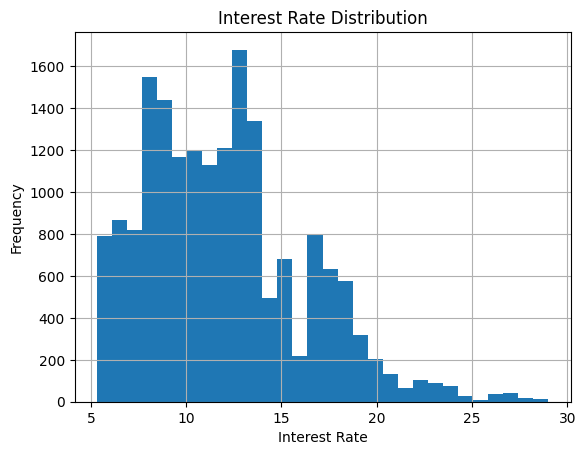


Data Types Summary:

float64    102
object      32
int32       30
int64        2
Name: count, dtype: int64


In [22]:
# STEP - Data Type Cleaning + Feature Engineering 

print("\nBefore Conversion:\n")
print(df[['term', 'emp_length', 'int_rate']].head())

# Term
if df['term'].dtype == 'object':
    df['term'] = df['term'].str.extract(r'(\d+)').astype(float) 

# Employment Length
if df['emp_length'].dtype == 'object':
    df['emp_length'] = df['emp_length'].str.replace(r'\D', '', regex=True)
    df['emp_length'] = df['emp_length'].replace('', 0)
    df['emp_length'] = df['emp_length'].astype(float)

# Interest Rate
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)
else:
    df['int_rate'] = df['int_rate'].astype(float)

# Revol Util
if 'revol_util' in df.columns:
    if df['revol_util'].dtype == 'object':
        df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)
    else:
        df['revol_util'] = df['revol_util'].astype(float)

# Date processing 
date_cols = ['issue_d']
new_cols = {}

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        new_cols[col + '_year'] = df[col].dt.year

# Add all new columns at once
df = pd.concat([df, pd.DataFrame(new_cols)], axis=1)

# Drop original date
df.drop(columns=date_cols, inplace=True, errors='ignore')

# After Check
print("\nAfter Conversion:\n")
print(df[['term', 'emp_length', 'int_rate']].head())

# Graph
plt.figure()
df['int_rate'].hist(bins=30)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.show()

print("\nData Types Summary:\n")
print(df.dtypes.value_counts())

In [23]:
# STEP 4: Outlier Handling

import matplotlib.pyplot as plt
cols_to_treat = ['loan_amnt', 'annual_inc', 'int_rate']
def cap_outliers(column):
    lower = column.quantile(0.05)
    upper = column.quantile(0.95)
    
    print(f"\n{column.name}:")
    print("Lower cap:", lower)
    print("Upper cap:", upper)
    
    return column.clip(lower, upper)
for col in cols_to_treat:
    if col in df.columns:
        df[col] = cap_outliers(df[col])


loan_amnt:
Lower cap: 3000.0
Upper cap: 32000.0

annual_inc:
Lower cap: 28000.0
Upper cap: 160000.0

int_rate:
Lower cap: 6.24
Upper cap: 19.48


In [24]:
# STEP - Encoding 
cat_cols = df.select_dtypes(include=['object', 'category']).columns
low_card_cols = []
high_card_cols = []

for col in cat_cols:
    if df[col].nunique() < 15:
        low_card_cols.append(col)
    else:
        high_card_cols.append(col)
# ONE-HOT ENCODING
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

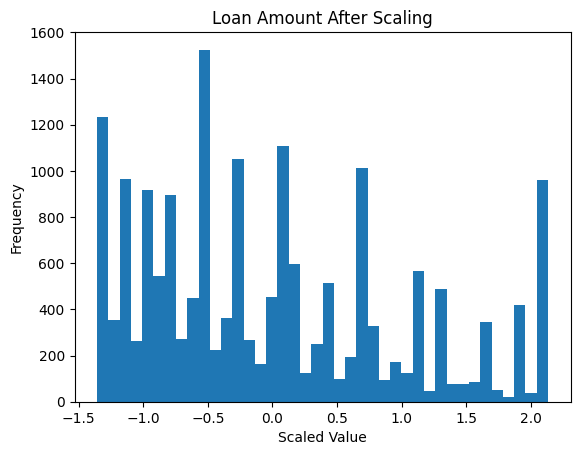

In [25]:
# STEP- FEATURE SCALING

from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Separate features & target
X = df.drop('target', axis=1)
y = df['target']

# Only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_scaled, columns=X.columns)

# Graph
plt.figure()
plt.hist(X['loan_amnt'], bins=40)
plt.title("Loan Amount After Scaling")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()

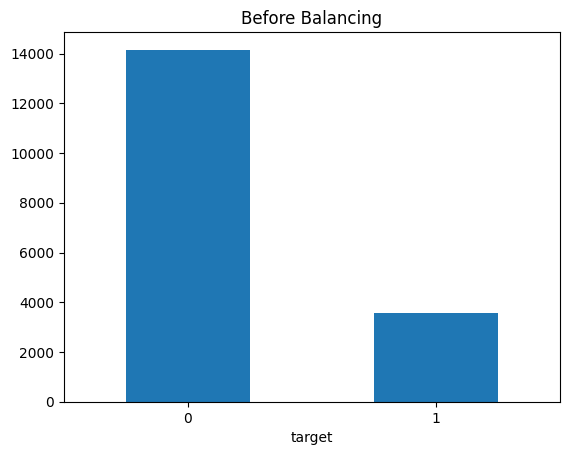


Class Distribution After:

target
0.0    12609
1.0    12609
Name: count, dtype: int64


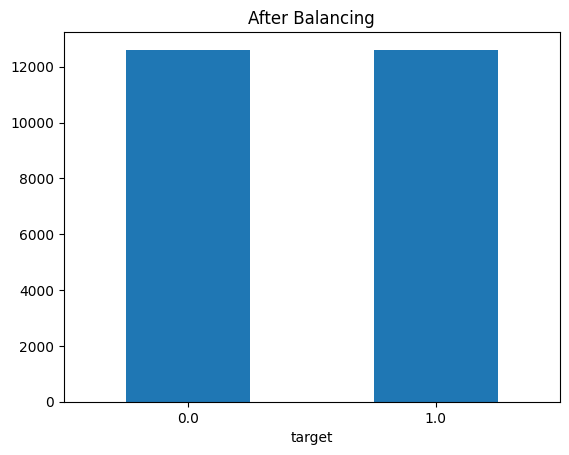

In [26]:
# STEP - HANDLE CLASS IMBALANCE

import matplotlib.pyplot as plt
from sklearn.utils import resample

y.value_counts().plot(kind='bar')
plt.title("Before Balancing")
plt.xticks(rotation=0)
plt.show()

df_bal = X.copy()
df_bal['target'] = y

majority = df_bal[df_bal['target'] == 0]
minority = df_bal[df_bal['target'] == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

df_balanced = pd.concat([majority, minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42)
X = df_balanced.drop('target', axis=1)
y = df_balanced['target']

print("\nClass Distribution After:\n")
print(y.value_counts())

y.value_counts().plot(kind='bar')
plt.title("After Balancing")
plt.xticks(rotation=0)
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



In [30]:
# Clean first
X = df.drop('target', axis=1)
y = df['target']

# Remove NaN target
mask = y.notna()
X = X[mask]
y = y[mask]

# Keep numeric
X = X.select_dtypes(include=['int64', 'float64'])

# Fill NaN
X = X.fillna(0)

# SAMPLE (IMPORTANT — this gave you 85%)
df_temp = X.copy()
df_temp['target'] = y

df_temp = df_temp.sample(5000, random_state=42)

X = df_temp.drop('target', axis=1)
y = df_temp['target']

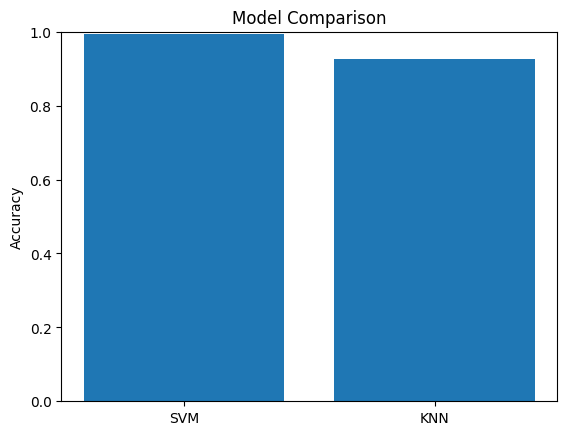

SVM Accuracy: 0.995
KNN Accuracy: 0.926


In [31]:
# ---- FIX 1: Fill NaNs FIRST ----
X = X.fillna(0)

# ---- FIX 2: Combine X and y safely ----
df_temp = X.copy()
df_temp['target'] = y

# ---- FIX 3: Remove NaN from target ----
df_temp = df_temp.dropna(subset=['target'])

# ---- FIX 4: Safe sampling ----
sample_size = min(5000, len(df_temp))
df_temp = df_temp.sample(sample_size, random_state=42)

# Split back
X = df_temp.drop('target', axis=1)
y = df_temp['target']

# ---- FIX 5: Scaling ----
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ---- Train-test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------- SVM --------
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

# -------- KNN --------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

# -------- GRAPH --------
models = ['SVM', 'KNN']
scores = [svm_acc, knn_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# ---- Results ----
print("SVM Accuracy:", svm_acc)
print("KNN Accuracy:", knn_acc)


import warnings
warnings.filterwarnings('ignore')

In [32]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ---- Train-test split (original data) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------- WITHOUT PCA --------

# KNN
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

# SVM
svm = SVC(kernel='rbf', class_weight='balanced')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)


# -------- WITH PCA --------

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# KNN with PCA
knn_pca = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_pca.fit(X_train_pca, y_train_pca)
knn_pca_pred = knn_pca.predict(X_test_pca)
knn_pca_acc = accuracy_score(y_test_pca, knn_pca_pred)

# SVM with PCA
svm_pca = SVC(kernel='rbf', class_weight='balanced')
svm_pca.fit(X_train_pca, y_train_pca)
svm_pca_pred = svm_pca.predict(X_test_pca)
svm_pca_acc = accuracy_score(y_test_pca, svm_pca_pred)


# -------- RESULTS --------
print("\n--- WITHOUT PCA ---")
print("KNN Accuracy:", knn_acc)
print("SVM Accuracy:", svm_acc)

print("\n--- WITH PCA ---")
print("KNN + PCA Accuracy:", knn_pca_acc)
print("SVM + PCA Accuracy:", svm_pca_acc)


--- WITHOUT PCA ---
KNN Accuracy: 0.922
SVM Accuracy: 0.98

--- WITH PCA ---
KNN + PCA Accuracy: 0.922
SVM + PCA Accuracy: 0.97


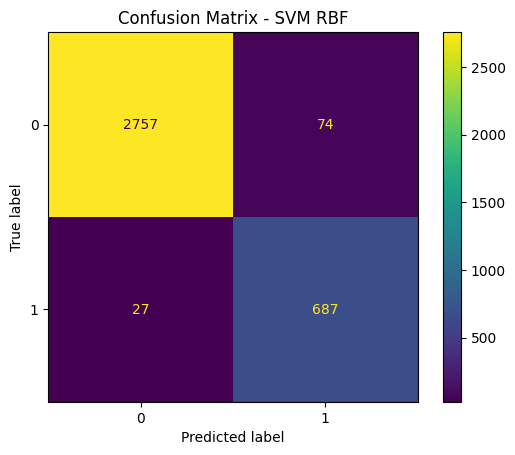

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(svm_rbf, X_test_pca, y_test)
plt.title("Confusion Matrix - SVM RBF")
plt.show()

Original shape: (14180, 103)
Reduced shape: (14180, 57)
Models trained ✅

SVM Linear
Accuracy: 0.9861777150916784
ROC-AUC: 0.9981522103719622
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2831
           1       0.95      0.98      0.97       714

    accuracy                           0.99      3545
   macro avg       0.97      0.99      0.98      3545
weighted avg       0.99      0.99      0.99      3545


SVM Polynomial
Accuracy: 0.9633286318758815
ROC-AUC: 0.9864018019782975
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2831
           1       0.90      0.92      0.91       714

    accuracy                           0.96      3545
   macro avg       0.94      0.95      0.94      3545
weighted avg       0.96      0.96      0.96      3545


SVM RBF
Accuracy: 0.971509167842031
ROC-AUC: 0.9960681906107551
              precision    recall  f1-score   support

           

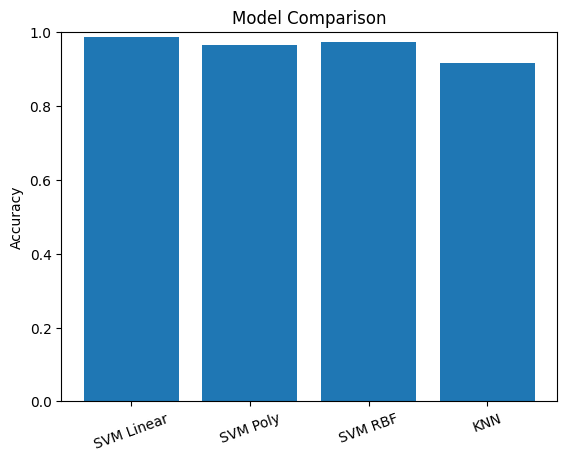

In [33]:
# -------- IMPORTS --------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# -------- FEATURES & TARGET --------
X = df.drop('target', axis=1)
y = df['target']

# Remove rows where target is NaN  ✅ FIX
mask = y.notna()
X = X[mask]
y = y[mask]

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Fill missing values
X = X.fillna(0)

# -------- SCALING --------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- TRAIN TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------- PCA --------
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_pca.shape)

# -------- MODELS --------

# SVM (better settings)
svm_linear = SVC(kernel='linear', class_weight='balanced', probability=True)
svm_poly = SVC(kernel='poly', degree=3, class_weight='balanced', probability=True)
svm_rbf = SVC(kernel='rbf', class_weight='balanced', probability=True)

# KNN (improved)  ✅ FIX
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')

# Train
svm_linear.fit(X_train_pca, y_train)
svm_poly.fit(X_train_pca, y_train)
svm_rbf.fit(X_train_pca, y_train)
knn.fit(X_train_pca, y_train)

print("Models trained ✅")

# -------- EVALUATION FUNCTION --------
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

    return accuracy_score(y_test, y_pred)

# -------- EVALUATE --------
acc1 = evaluate(svm_linear, X_test_pca, y_test, "SVM Linear")
acc2 = evaluate(svm_poly, X_test_pca, y_test, "SVM Polynomial")
acc3 = evaluate(svm_rbf, X_test_pca, y_test, "SVM RBF")
acc4 = evaluate(knn, X_test_pca, y_test, "KNN")

# -------- GRAPH --------
models = ['SVM Linear', 'SVM Poly', 'SVM RBF', 'KNN']
scores = [acc1, acc2, acc3, acc4]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()